# 01 · Simulasi Data

**Tujuan:** membangkitkan data saldo dana harian beberapa bank fiktif dan memahami
skenario yang akan diuji.

Mengapa simulasi?
1. Data antar bank sungguhan bersifat rahasia (inilah masalah yang ingin dipecahkan
   federated learning).
2. Pada data simulasi, **distribusi sebenarnya diketahui**, sehingga kita bisa menguji
   dengan tepat apakah interval prediksi model memang "jujur".

Model setiap bank *k* pada hari *t*:

$$y_k(t) = S_k\,[\,D_k(t) + \beta_k M(t) + I_k(t) + \sigma_k(t)\,\varepsilon_k(t)\,]$$

| Komponen | Arti |
|---|---|
| $S_k$ | ukuran bank (besar/menengah/kecil) |
| $D_k(t)$ | tren + pola mingguan + efek gajian + efek Lebaran (+ shock) |
| $M(t)$ | faktor pasar bersama (AR(1)), dirasakan semua bank |
| $I_k(t)$ | faktor khusus bank (AR(1)) |
| $\sigma_k(t)\varepsilon_k(t)$ | noise, volatilitas bisa naik saat shock |

Parameter **alpha** mengatur heterogenitas: 0 = semua bank berpola sama, 1 = sangat berbeda (non-IID).

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 110

In [2]:
from fedprob.data import SCENARIOS, SCENARIO_DESCRIPTIONS, get_scenario, simulate
from fedprob.plots import plot_series

sim = simulate(get_scenario("normal"))
sim.to_frame().head()

,Bank A,Bank B,Bank C,Bank D,Bank E,Bank F,Bank G,Bank H
2023-01-01,4113.218,6220.735,1305.085,1179.256,1672.417,278.611,320.771,305.176
2023-01-02,4191.600,6405.297,1346.012,1216.000,1667.872,280.466,329.313,321.052
2023-01-03,4137.712,6020.814,1335.170,1186.143,1593.681,277.798,314.269,310.980
2023-01-04,4058.321,6220.950,1346.216,1185.723,1595.294,274.022,317.021,315.470
2023-01-05,4010.169,6162.864,1347.210,1183.928,1612.364,274.286,321.319,322.147


In [3]:
pd.DataFrame([{ "bank": b.name, "ukuran": b.size, "skala": b.scale, "tren/thn": b.trend,
                "beta_pasar": b.beta, "noise_sd": b.noise_sd } for b in sim.banks])

,bank,ukuran,skala,tren/thn,beta_pasar,noise_sd
0,Bank A,besar,41.275,8.731,1.169,1.019
1,Bank B,besar,62.666,10.108,0.877,0.938
2,Bank C,menengah,14.071,7.727,1.117,0.905
3,Bank D,menengah,11.958,6.871,1.269,0.777
4,Bank E,menengah,16.401,5.793,1.124,1.098
5,Bank F,kecil,2.803,9.597,0.986,0.820
6,Bank G,kecil,3.222,10.017,1.043,1.011
7,Bank H,kecil,3.165,11.512,0.833,1.100


Series asli: perbedaan skala antar bank sangat besar. Inilah alasan setiap bank dinormalisasi sendiri-sendiri.

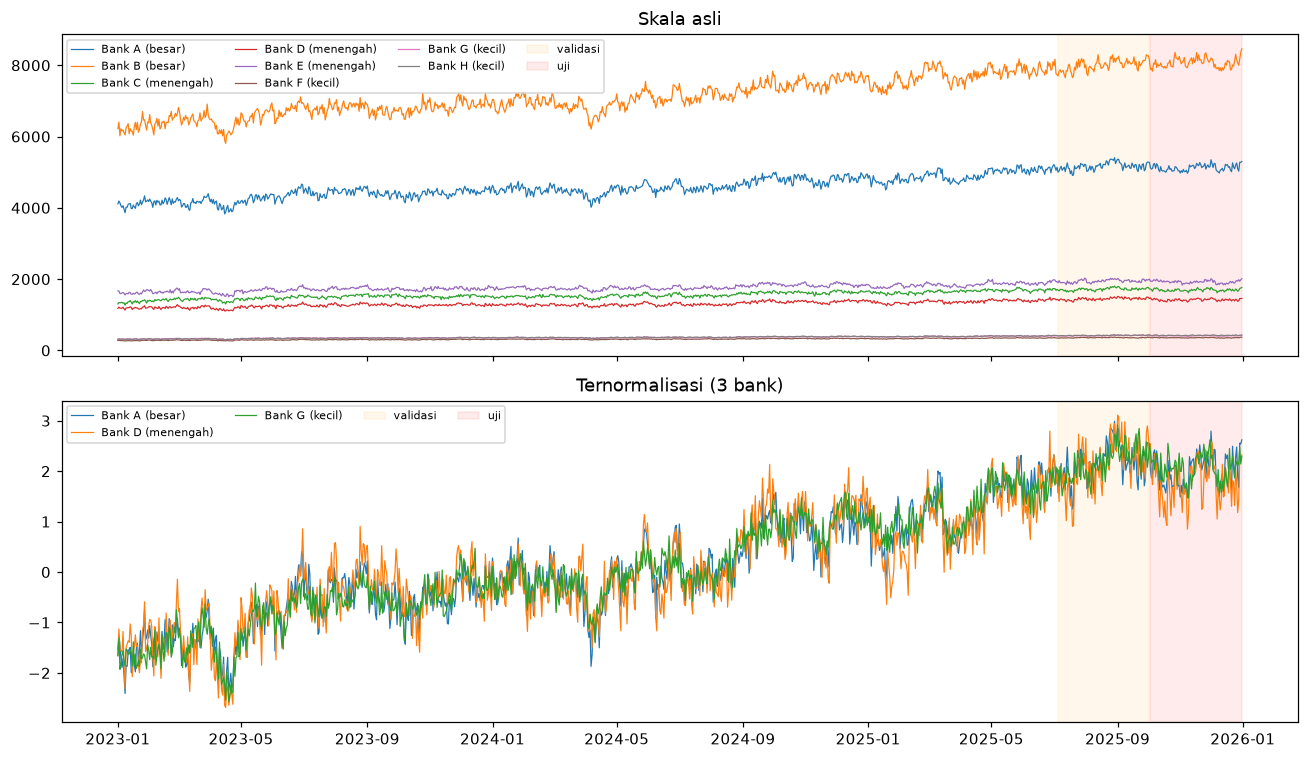

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
plot_series(sim, ax=axes[0], title="Skala asli")
plot_series(sim, normalize=True, banks=[0, 3, 6], ax=axes[1], title="Ternormalisasi (3 bank)")
plt.tight_layout()

Zoom 4 bulan: terlihat pola mingguan, lonjakan sekitar tanggal gajian, dan penurunan menjelang Lebaran.

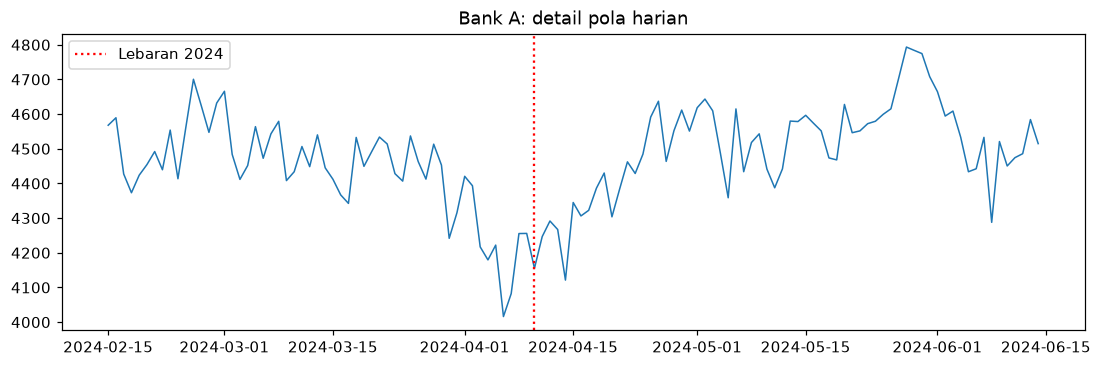

In [5]:
s = slice(sim.dates.get_loc("2024-02-15"), sim.dates.get_loc("2024-06-15"))
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(sim.dates[s], sim.y[s, 0], lw=1)
ax.axvline(pd.Timestamp("2024-04-10"), color="red", ls=":", label="Lebaran 2024")
ax.set_title(f"{sim.banks[0].name}: detail pola harian"); ax.legend()

## Skenario yang disiapkan

In [6]:
for name, desc in SCENARIO_DESCRIPTIONS.items():
    print(f"{name:12s} : {desc}")

normal       : Kondisi dasar: 8 bank dengan pola cukup mirip (alpha=0.3).
heterogen    : Pola tiap bank sangat berbeda (alpha=0.9) -- data non-IID.
data_langka  : Bank kecil F, G, H hanya punya ~4 bulan histori.
shock        : Guncangan bersama (penarikan dana besar + volatilitas naik) di periode uji.
bank_baru    : Bank H baru bergabung dengan histori ~8 bulan.
klaster      : Dua kelompok bank (mis. ritel vs korporat) dengan pola sangat berbeda.


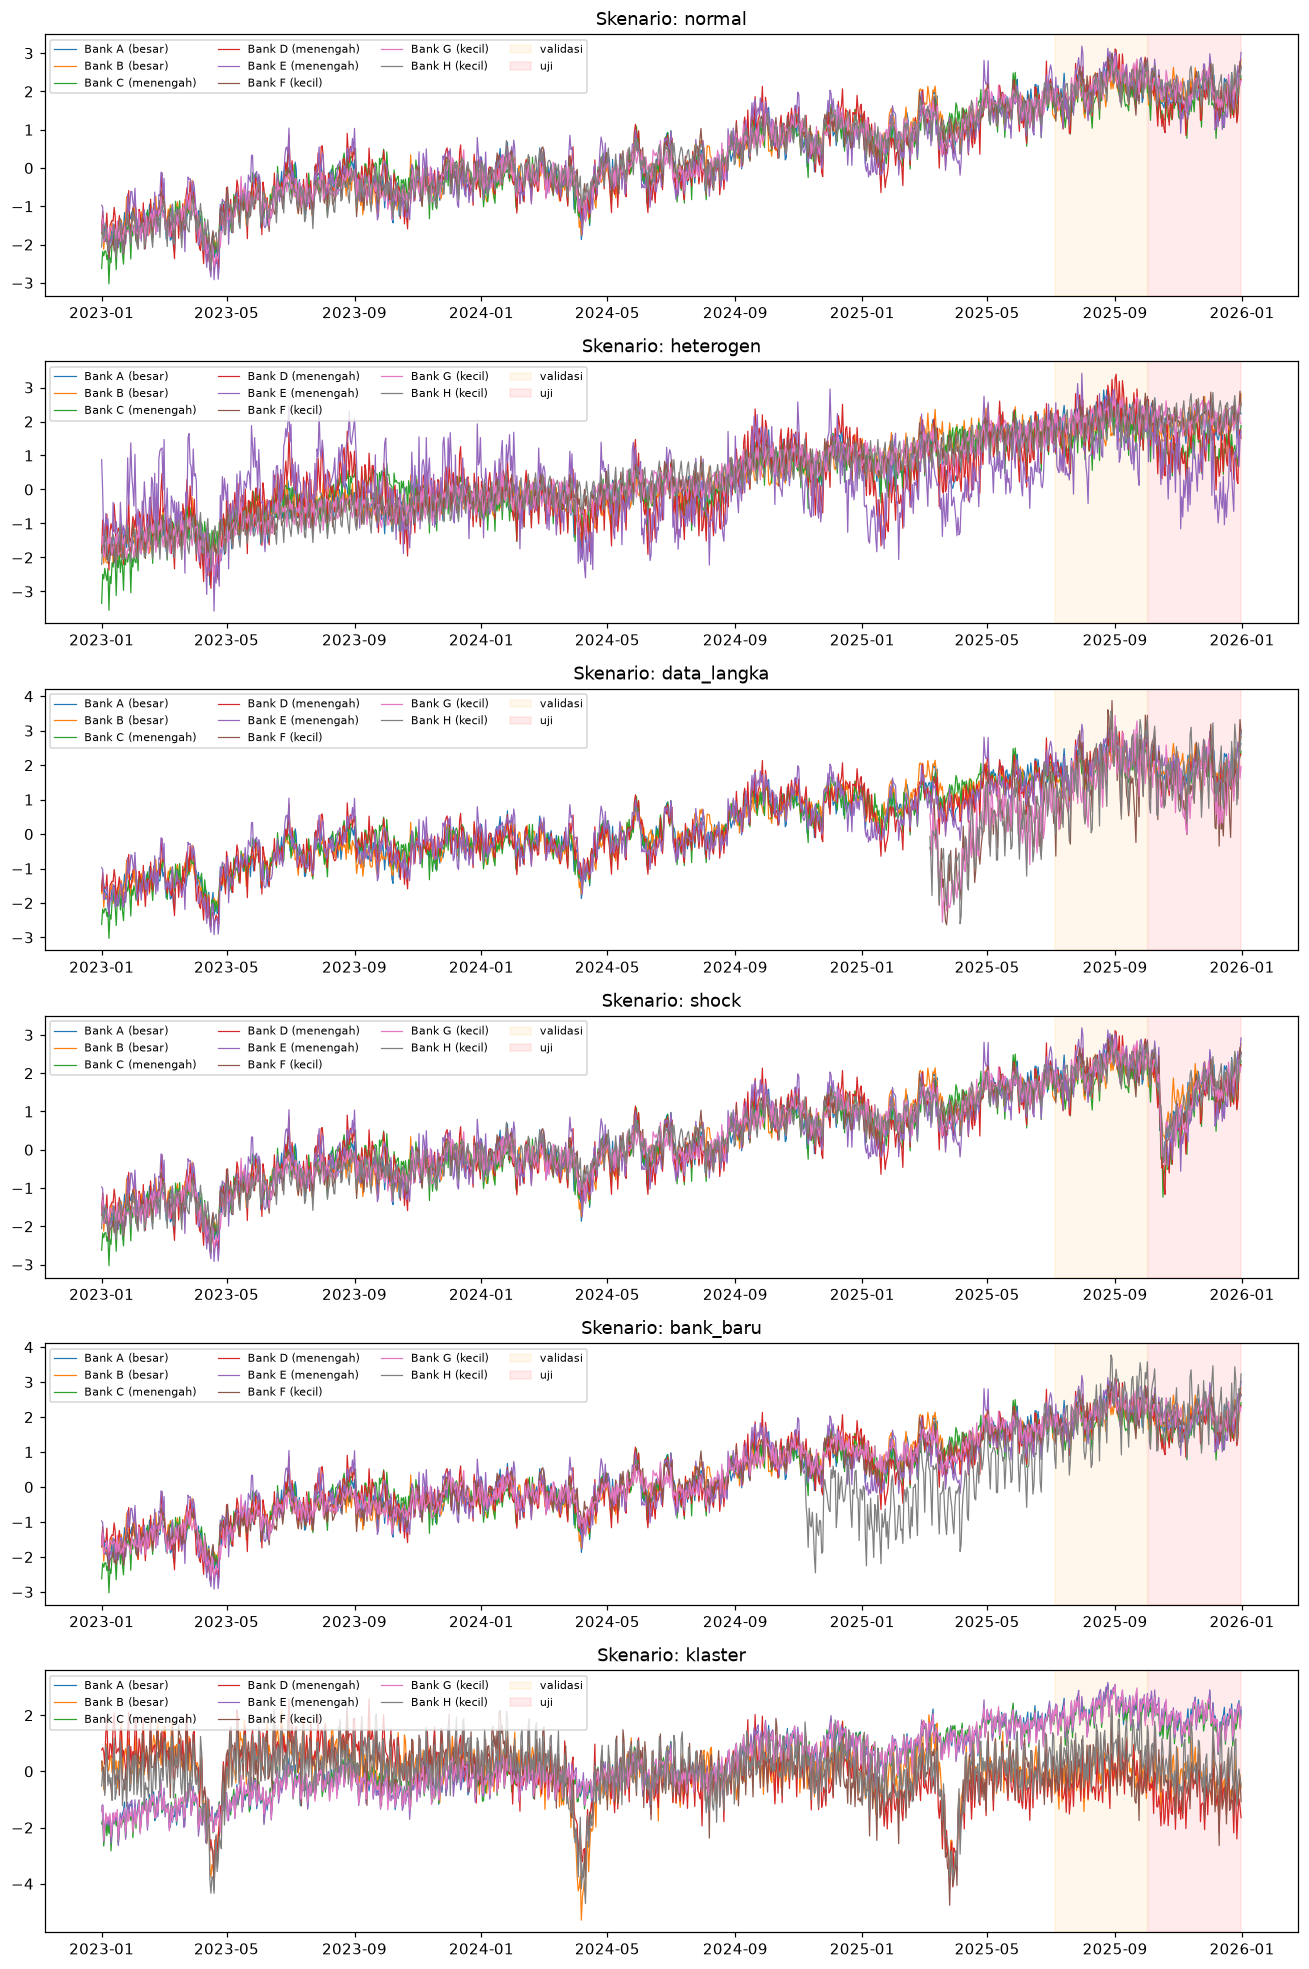

In [7]:
fig, axes = plt.subplots(len(SCENARIOS), 1, figsize=(12, 3 * len(SCENARIOS)))
for ax, name in zip(axes, SCENARIOS):
    plot_series(simulate(get_scenario(name)), normalize=True, ax=ax, title=f"Skenario: {name}")
plt.tight_layout()

## Pembagian data (tanpa kebocoran waktu)
- **train**: semua sebelum 180 hari terakhir
- **validasi**: 90 hari (untuk memilih epoch/ronde terbaik)
- **uji**: 90 hari terakhir (forecast 14 hari ke depan, origin setiap hari → 77 origin per bank)

Normalisasi: setiap bank diskalakan **relatif terhadap saldo rata-ratanya** (1 unit = 5% saldo
rata-rata), sehingga bank besar dan kecil berada di skala yang sama. Normalisasi mean/std biasa
ternyata gagal untuk bank berhistori pendek (lihat `PROGRESS.md`).

Input model: 56 hari terakhir + fitur kalender hari-hari target (hari, gajian, Lebaran, musim).

In [8]:
from fedprob.data import build_all_clients
clients = build_all_clients(sim)
pd.DataFrame([{ "bank": c.name, "n_train": len(c.train), "n_val": len(c.val), "n_test": len(c.test)} for c in clients])

,bank,n_train,n_val,n_test
0,Bank A,847,77,77
1,Bank B,847,77,77
2,Bank C,847,77,77
3,Bank D,847,77,77
4,Bank E,847,77,77
5,Bank F,847,77,77
6,Bank G,847,77,77
7,Bank H,847,77,77
